<a href="https://colab.research.google.com/github/AustinChinn03/DS3001Final/blob/main/DataAnalyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!git clone https://github.com/AustinChinn03/DS3001Final.git

Cloning into 'DS3001Final'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 27 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 362.07 KiB | 8.62 MiB/s, done.
Resolving deltas: 100% (12/12), done.


#### Load Data

In [3]:
# Import csv and drop unnecessary column
fry = pd.read_csv("DS3001Final/air_fryers_clean_brand_year.csv")
fry = fry.drop(columns = "category")

fry.head()

,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [4]:
# Verify data range and number of categories
print("Number of brands: " + str(fry['brand'].nunique()))
print("Time range: " + str(fry['year'].min()) + " - " + str(fry['year'].max()))


Number of brands: 10
Time range: 2019 - 2023


#### Plot Trends over Time

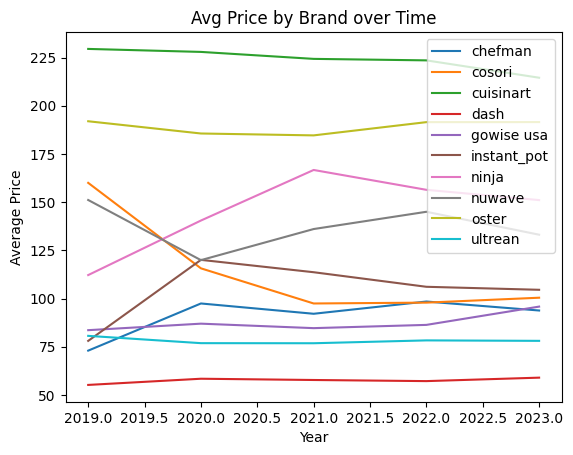

In [24]:
# Plot average price over time for each brand
for brand, data in fry.groupby('brand'):
    plt.plot(data['year'], data['avg_price'], label=brand)

plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Avg Price by Brand over Time')
plt.legend()
plt.show()

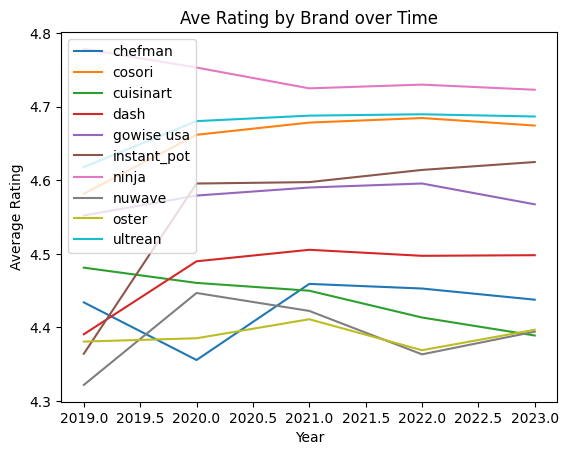

In [23]:
# Plot average rating over time for each brand
for brand, data in fry.groupby('brand'):
    plt.plot(data['year'], data['avg_rating'], label=brand)

plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Ave Rating by Brand over Time')
plt.legend()
plt.show()

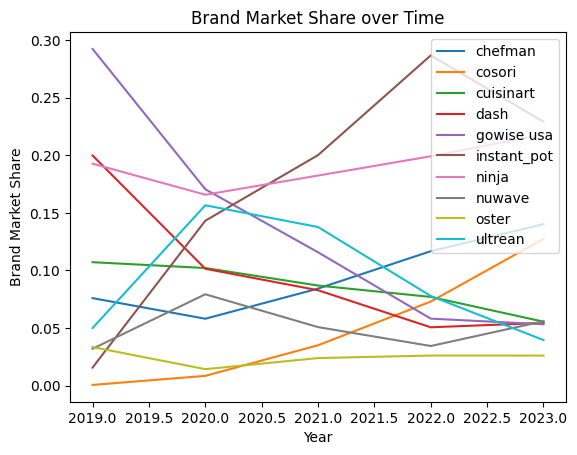

In [25]:
# Plot market share over time for each brand
for brand, data in fry.groupby('brand'):
    plt.plot(data['year'], data['brand_share'], label=brand)

plt.xlabel('Year')
plt.ylabel('Brand Market Share')
plt.title('Brand Market Share over Time')
plt.legend()
plt.show()

#### Summarize Product Characteristics:

In [21]:
# Store target feature columns
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

# Calculate market share averages for each feature
feature_summary = fry[feature_cols].mean().sort_values(ascending=False)
print(feature_summary)

## Identify brand specialization

# List rare features
special_cols = [
    "dual_basket_share",
    "rotisserie_share",
    "window_share"
]

# Identify rare feature with highest market share by brand
brand_features = fry.groupby("brand")[special_cols].mean()
brand_features["dominant_feature"] = brand_features.idxmax(axis=1)
print(brand_features[["dominant_feature"]])


compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64
              dominant_feature
brand                         
chefman       rotisserie_share
cosori        rotisserie_share
cuisinart    dual_basket_share
dash         dual_basket_share
gowise usa    rotisserie_share
instant_pot   rotisserie_share
ninja        dual_basket_share
nuwave        rotisserie_share
oster        dual_basket_share
ultrean      dual_basket_share


#### Market summary:

The premium brands are Cuisinart and Oster which represent a small share of the market, with Ninja dominating the next-highest price range. Each of the premium brands appear to specialize in the dual-basket feature, which indicates that this feature comes with a premium. We see that price and rating do not necessarily go hand in hand, although Ninja seems to be an exception, with consistently high ratings, high market share, and a mid-high price point. Compact air fryers represent a large portion of the market share, with oven-style fryers being the next most desired feature. Cost and rating seem to both be stable over time with a couple of exceptions, whereas market share has gotten shaken up over time. One brand that has drastically changed the market over time is Instant Pot, which has grown massively in market share while increasing ratings and decreasing price.